## 1. Setup

The notebook uses the same multilingual MAGPIE checkpoint as the main German analysis. The English-language BABE and SemEval analyses use the English-only MAGPIE checkpoint instead. A GPU is used when available because sentence-level Transformer inference is the main computational step.

### Run order

Run the notebook **from top to bottom**. The final results are generated from the current sample and scoring variables rather than being typed into the notebook.

In [1]:
# Install packages required for the analysis.
!pip install -q transformers pandas scipy statsmodels tqdm matplotlib


In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [2]:
import os
import re
import statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import torch

from scipy.stats import mannwhitneyu, spearmanr
from tqdm import tqdm
from transformers import pipeline

MODEL_NAME = "mediabiasgroup/magpie-babe-ft-xlm"
RANDOM_SEED = 42

device = 0 if torch.cuda.is_available() else -1
print("Model device:", "GPU" if device == 0 else "CPU")

bias_classifier = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=device,
)


Model device: GPU


config.json:   0%|          | 0.00/835 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

## 2. Load the Spanish corpus and build the reproducible sample

The Spanish PoliOscar file is loaded as a tab-separated corpus. Article text can contain line breaks, so the loader keeps continuation lines as part of the current article record instead of assuming that every physical line is a complete record.

Articles with empty text are removed **before sampling**. The final sample contains 500 left-labelled and 500 right-labelled articles, selected with `random_state=42`.

This follows the final German sampling procedure so that the comparison is based on usable article text rather than on records that cannot be scored.


In [3]:
# Read the Spanish OSCAR corpus from the Colab working directory.

FILE = "poliOscar.complete.es"

print("Input file:", FILE)

Input file: poliOscar.complete.es


In [4]:
# Read the corpus while preserving line breaks within article text.

columns = ["topic10", "topic15", "stance", "oscarID", "url", "text"]

rows = []
current = None

with open(FILE, "r", encoding="utf-8") as f:
    for raw_line in f:
        line = raw_line.rstrip("\r\n")
        parts = line.split("\t", 5)

        if len(parts) >= 5 and parts[2] in ["left", "right"]:
            if current is not None:
                rows.append(current)

            while len(parts) < 6:
                parts.append("")

            current = parts[:6]
        elif current is not None:
            current[5] += "\n" + line

if current is not None:
    rows.append(current)

df = pd.DataFrame(rows, columns=columns)

print("Full corpus shape:", df.shape)
print("\nStance distribution:")
print(df["stance"].value_counts())

print("\nRecords with empty text:", df["text"].fillna("").str.strip().eq("").sum())

assert {"left", "right"}.issubset(set(df["stance"].dropna().unique()))
assert df["oscarID"].notna().all()
assert df["url"].notna().all()


Full corpus shape: (301825, 6)

Stance distribution:
stance
right    153696
left     148129
Name: count, dtype: int64

Records with empty text: 0


In [5]:
# Keep only articles with usable text before drawing the balanced sample.
df_usable = df[df["text"].fillna("").str.strip().ne("")].copy()

left_available = (df_usable["stance"] == "left").sum()
right_available = (df_usable["stance"] == "right").sum()

print("Usable articles:", len(df_usable))
print("Usable left articles:", left_available)
print("Usable right articles:", right_available)

assert left_available >= 500
assert right_available >= 500

left_sample = df_usable[df_usable["stance"] == "left"].sample(
    n=500, random_state=RANDOM_SEED
)
right_sample = df_usable[df_usable["stance"] == "right"].sample(
    n=500, random_state=RANDOM_SEED
)

df_sample = (
    pd.concat([left_sample, right_sample])
    .sample(frac=1, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

print("\nSample shape:", df_sample.shape)
print("\nStance counts:")
print(df_sample["stance"].value_counts())

print("\nUnique oscarID values:", df_sample["oscarID"].nunique())
print("Unique URL values:", df_sample["url"].nunique())
print("Duplicate oscarID count:", df_sample["oscarID"].duplicated().sum())
print("Duplicate URL count:", df_sample["url"].duplicated().sum())

assert len(df_sample) == 1000
assert df_sample["stance"].value_counts().to_dict() == {"left": 500, "right": 500}
assert df_sample["text"].str.strip().ne("").all()
assert df_sample["oscarID"].nunique() == 1000


Usable articles: 301825
Usable left articles: 148129
Usable right articles: 153696

Sample shape: (1000, 6)

Stance counts:
stance
right    500
left     500
Name: count, dtype: int64

Unique oscarID values: 1000
Unique URL values: 1000
Duplicate oscarID count: 0
Duplicate URL count: 0


## 3. Sentence splitting and MAGPIE scoring

MAGPIE produces a sentence-level probability for the `biased` class. These predictions are aggregated into several article-level measures.

The **continuous average** is the primary average-pooling measure because it preserves the model's probability information. The hard-label proportion is retained only as a sensitivity measure. Maximum and median pooling use the continuous sentence-level probabilities.


In [8]:
import re

def split_into_sentences(text):
    sentences = re.split(r'(?<=[.!?]) +', text)
    return [s.strip() for s in sentences if len(s.strip()) > 0]

In [9]:
def score_article(text, classifier, batch_size=32):
    if pd.isna(text) or not text.strip():
        return None, None, None, None, None, None

    sentences = split_into_sentences(text)
    if not sentences:
        return None, None, None, None, None, None

    results = classifier(
        sentences,
        truncation=True,
        batch_size=batch_size
    )

    labels = [result["label"] for result in results]
    biased_probs = [
        result["score"] if result["label"] == "biased" else 1 - result["score"]
        for result in results
    ]

    continuous_avg = float(np.mean(biased_probs))
    hard_avg = labels.count("biased") / len(labels)
    max_score = max(biased_probs)
    median_score = statistics.median(biased_probs)

    sorted_probs = sorted(biased_probs, reverse=True)
    top3_score = float(np.mean(sorted_probs[:min(3, len(sorted_probs))]))
    top5_score = float(np.mean(sorted_probs[:min(5, len(sorted_probs))]))

    return (
        continuous_avg,
        hard_avg,
        max_score,
        median_score,
        top3_score,
        top5_score,
    )


In [10]:
# Score each sampled article once and derive all pooling measures from the same sentence-level predictions.
scored = []

for text in tqdm(
    df_sample["text"],
    total=len(df_sample),
    desc="Scoring articles"
):
    scored.append(score_article(text, bias_classifier))

(
    continuous_avg_scores,
    hard_avg_scores,
    max_scores,
    median_scores,
    top3_scores,
    top5_scores,
) = map(list, zip(*scored))

df_sample["bias_score_continuous"] = continuous_avg_scores
df_sample["bias_score"] = hard_avg_scores
df_sample["max_bias_score"] = max_scores
df_sample["median_bias_score"] = median_scores
df_sample["top3_avg"] = top3_scores
df_sample["top5_avg"] = top5_scores

print("Scored articles:", df_sample["bias_score_continuous"].notna().sum())
print("Unscored articles:", df_sample["bias_score_continuous"].isna().sum())

assert df_sample["bias_score_continuous"].notna().all()


Scoring articles: 100%|██████████| 1000/1000 [01:15<00:00, 13.30it/s]

Scored articles: 1000
Unscored articles: 0


## 4. Primary left/right comparisons

The primary comparisons examine whether article-level MAGPIE scores differ between the left- and right-labelled groups.

The continuous average, maximum, and median measures are tested with two-sided Mann–Whitney U tests. The hard-label average is reported separately as a sensitivity analysis.

In [11]:
def compare_groups(column):
    left = df_sample.loc[df_sample["stance"] == "left", column].dropna()
    right = df_sample.loc[df_sample["stance"] == "right", column].dropna()

    u_stat, p_value = mannwhitneyu(left, right, alternative="two-sided")

    # Positive values indicate higher values in the left group under this definition.
    rank_biserial = 1 - (2 * u_stat) / (len(left) * len(right))

    return {
        "left_n": len(left),
        "right_n": len(right),
        "left_mean": left.mean(),
        "right_mean": right.mean(),
        "left_median": left.median(),
        "right_median": right.median(),
        "u": u_stat,
        "p": p_value,
        "rank_biserial": rank_biserial,
    }


primary_results = {
    "Continuous average": compare_groups("bias_score_continuous"),
    "Maximum": compare_groups("max_bias_score"),
    "Median": compare_groups("median_bias_score"),
}

for method, result in primary_results.items():
    print(
        f"{method}: "
        f"left mean={result['left_mean']:.4f}, "
        f"right mean={result['right_mean']:.4f}, "
        f"p={result['p']:.4f}, "
        f"rank-biserial={result['rank_biserial']:.4f}"
    )

hard_avg_result = compare_groups("bias_score")
print(
    f"\nHard-label average sensitivity: "
    f"left mean={hard_avg_result['left_mean']:.4f}, "
    f"right mean={hard_avg_result['right_mean']:.4f}, "
    f"p={hard_avg_result['p']:.4f}, "
    f"rank-biserial={hard_avg_result['rank_biserial']:.4f}"
)


Continuous average: left mean=0.2549, right mean=0.2355, p=0.0144, rank-biserial=-0.0894
Maximum: left mean=0.8149, right mean=0.7640, p=0.0268, rank-biserial=-0.0809
Median: left mean=0.1653, right mean=0.1552, p=0.0493, rank-biserial=-0.0718

Hard-label average sensitivity: left mean=0.1995, right mean=0.1809, p=0.0210, rank-biserial=-0.0841


## 5. Article length and regression checks

Article length is considered because pooling sentence-level scores can be affected by the number of sentences in an article. Maximum pooling is especially sensitive because longer articles provide more opportunities for a high sentence-level score.

Regression models therefore test whether the stance difference remains after controlling for sentence count. HC3 robust standard errors are included as a sensitivity check.


In [12]:
df_sample["num_sentences"] = df_sample["text"].apply(
    lambda text: len(split_into_sentences(text))
)

print("Mean sentence count by stance:")
print(df_sample.groupby("stance")["num_sentences"].mean())

print("\nSentence-count summary by stance:")
print(df_sample.groupby("stance")["num_sentences"].describe())

print("\nCorrelations:")
print(
    df_sample[
        [
            "num_sentences",
            "bias_score_continuous",
            "bias_score",
            "max_bias_score",
            "median_bias_score",
        ]
    ].corr()
)


Mean sentence count by stance:
stance
left     31.518
right    31.108
Name: num_sentences, dtype: float64

Sentence-count summary by stance:
        count    mean        std  min   25%   50%    75%    max
stance                                                         
left    500.0  31.518  28.028144  1.0  15.0  24.0  38.25  201.0
right   500.0  31.108  39.438600  1.0  14.0  21.5  34.25  467.0

Correlations:
                       num_sentences  bias_score_continuous  bias_score  \
num_sentences               1.000000               0.126424    0.098659   
bias_score_continuous       0.126424               1.000000    0.959743   
bias_score                  0.098659               0.959743    1.000000   
max_bias_score              0.321455               0.561198    0.530862   
median_bias_score           0.074731               0.901739    0.866726   

                       max_bias_score  median_bias_score  
num_sentences                0.321455           0.074731  
bias_score_continuo

In [13]:
# Encode left as 1 and right as 0 for the regression coefficient.
df_sample["stance_numeric"] = (df_sample["stance"] == "left").astype(int)

models = {}

for score_name, formula in {
    "Continuous average": "bias_score_continuous ~ stance_numeric + num_sentences",
    "Hard-label average": "bias_score ~ stance_numeric + num_sentences",
    "Maximum": "max_bias_score ~ stance_numeric + num_sentences",
    "Median": "median_bias_score ~ stance_numeric + num_sentences",
}.items():
    model = smf.ols(formula, data=df_sample).fit()
    models[score_name] = model

    print(f"\n### {score_name}")
    print(model.summary())



### Continuous average
                              OLS Regression Results                             
Dep. Variable:     bias_score_continuous   R-squared:                       0.020
Model:                               OLS   Adj. R-squared:                  0.018
Method:                    Least Squares   F-statistic:                     10.20
Date:                   Tue, 22 Sep 2026   Prob (F-statistic):           4.14e-05
Time:                           15:07:53   Log-Likelihood:                 482.26
No. Observations:                   1000   AIC:                            -958.5
Df Residuals:                        997   BIC:                            -943.8
Df Model:                              2                                         
Covariance Type:               nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

In [14]:
# HC3 robust standard errors as a sensitivity check.
for score_name, model in models.items():
    robust = model.get_robustcov_results(cov_type="HC3")
    stance_idx = list(model.params.index).index("stance_numeric")

    print(
        f"{score_name}: "
        f"stance coef={robust.params[stance_idx]:.4f}, "
        f"HC3 p={robust.pvalues[stance_idx]:.4f}, "
        f"95% CI=({robust.conf_int()[stance_idx, 0]:.4f}, "
        f"{robust.conf_int()[stance_idx, 1]:.4f})"
    )


Continuous average: stance coef=0.0192, HC3 p=0.0430, 95% CI=(0.0006, 0.0379)
Hard-label average: stance coef=0.0184, HC3 p=0.1078, 95% CI=(-0.0040, 0.0408)
Maximum: stance coef=0.0499, HC3 p=0.0019, 95% CI=(0.0185, 0.0813)
Median: stance coef=0.0100, HC3 p=0.3753, 95% CI=(-0.0121, 0.0321)


## 6. Restricted-length sensitivity analysis

A second check restricts the sample to articles containing between 10 and 60 sentences, matching the range used in the German analysis.

This is described as a **restricted-length sensitivity analysis**, not as a formally matched sample. It narrows the range of article lengths but does not remove all possible confounding.


In [15]:
df_restricted = df_sample[
    df_sample["num_sentences"].between(10, 60)
].copy()

print("Restricted sample shape:", df_restricted.shape)
print("\nRestricted sample by stance:")
print(df_restricted["stance"].value_counts())

print("\nSentence-count summary:")
print(df_restricted.groupby("stance")["num_sentences"].describe())

left_restricted = df_restricted.loc[
    df_restricted["stance"] == "left", "max_bias_score"
].dropna()

right_restricted = df_restricted.loc[
    df_restricted["stance"] == "right", "max_bias_score"
].dropna()

u_restricted, p_restricted = mannwhitneyu(
    left_restricted,
    right_restricted,
    alternative="two-sided"
)

rank_biserial_restricted = (
    1 - (2 * u_restricted) / (len(left_restricted) * len(right_restricted))
)

print(
    f"\nRestricted max pooling: "
    f"left mean={left_restricted.mean():.4f}, "
    f"right mean={right_restricted.mean():.4f}, "
    f"p={p_restricted:.4f}, "
    f"rank-biserial={rank_biserial_restricted:.4f}"
)


Restricted sample shape: (769, 14)

Restricted sample by stance:
stance
left     385
right    384
Name: count, dtype: int64

Sentence-count summary:
        count       mean        std   min   25%   50%   75%   max
stance                                                           
left    385.0  27.054545  12.444026  10.0  18.0  25.0  34.0  60.0
right   384.0  25.562500  12.034817  10.0  16.0  22.0  31.0  58.0

Restricted max pooling: left mean=0.8464, right mean=0.7962, p=0.1151, rank-biserial=-0.0657


## 7. Robustness with top-k pooling

Top-3 and top-5 pooling focus on the highest sentence-level MAGPIE probabilities within an article. They are derived from the same sentence-level predictions as the other pooling measures, so the model does not need to be run again.

These results are additional robustness analyses rather than additional primary hypothesis tests.


In [16]:
for column in ["top3_avg", "top5_avg"]:
    result = compare_groups(column)
    print(
        f"{column}: left mean={result['left_mean']:.4f}, "
        f"right mean={result['right_mean']:.4f}, "
        f"p={result['p']:.4f}, "
        f"rank-biserial={result['rank_biserial']:.4f}"
    )

print("\nTop-k measures are not included in the primary six-test Bonferroni family.")


top3_avg: left mean=0.7082, right mean=0.6360, p=0.0040, rank-biserial=-0.1051
top5_avg: left mean=0.6248, right mean=0.5572, p=0.0024, rank-biserial=-0.1110

Top-k measures are not included in the primary six-test Bonferroni family.


## 8. Multiple-testing correction for the primary six-test family

Six tests are treated as the primary hypothesis family, using the same six-test structure defined for the German analysis:

1. continuous average pooling
2. naive maximum pooling
3. maximum pooling with length regression
4. restricted-length maximum pooling
5. naive median pooling
6. median pooling with length regression

The hard-label average and top-k measures are sensitivity/robustness analyses and are not added to this primary family.

In [17]:
primary_p_values = {
    "Continuous average": primary_results["Continuous average"]["p"],
    "Maximum (naive)": primary_results["Maximum"]["p"],
    "Maximum + length regression": models["Maximum"].pvalues["stance_numeric"],
    "Restricted-length maximum": p_restricted,
    "Median (naive)": primary_results["Median"]["p"],
    "Median + length regression": models["Median"].pvalues["stance_numeric"],
}

corrected_alpha = 0.05 / len(primary_p_values)

print(f"Bonferroni threshold: {corrected_alpha:.4f}\n")

for method, p_value in primary_p_values.items():
    status = "significant" if p_value < corrected_alpha else "not significant"
    print(f"{method}: p={p_value:.4f} -> {status}")


Bonferroni threshold: 0.0083

Continuous average: p=0.0144 -> not significant
Maximum (naive): p=0.0268 -> not significant
Maximum + length regression: p=0.0018 -> significant
Restricted-length maximum: p=0.1151 -> not significant
Median (naive): p=0.0493 -> not significant
Median + length regression: p=0.3739 -> not significant


## 9. Visualisation

The following figures provide a simple visual check of the maximum MAGPIE score distribution and its relationship with article length.


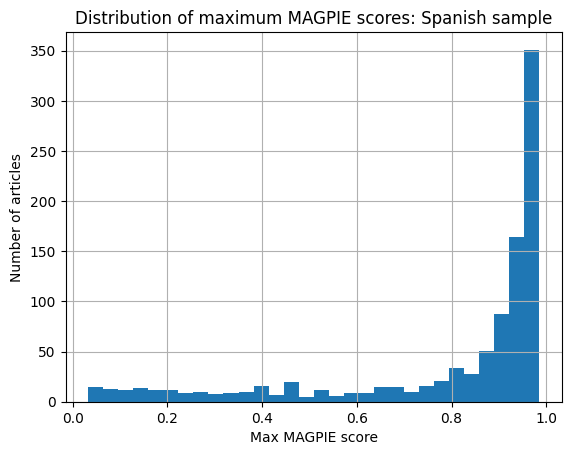

In [18]:
fig, ax = plt.subplots()
df_sample["max_bias_score"].hist(bins=30, ax=ax)
ax.set_xlabel("Max MAGPIE score")
ax.set_ylabel("Number of articles")
ax.set_title("Distribution of maximum MAGPIE scores: Spanish sample")
plt.show()


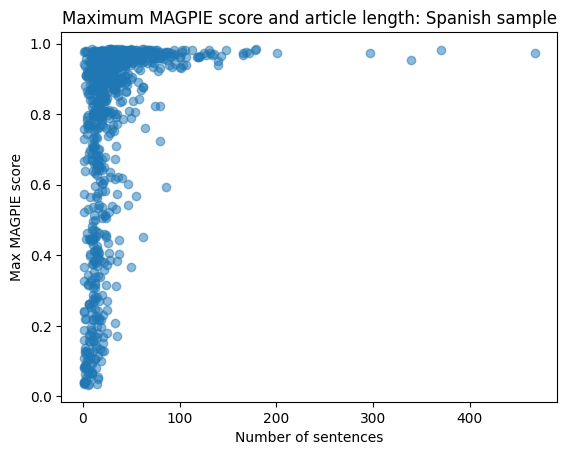

In [19]:
fig, ax = plt.subplots()
ax.scatter(
    df_sample["num_sentences"],
    df_sample["max_bias_score"],
    alpha=0.5
)
ax.set_xlabel("Number of sentences")
ax.set_ylabel("Max MAGPIE score")
ax.set_title("Maximum MAGPIE score and article length: Spanish sample")
plt.show()


## 10. Final result summary

The final summary is generated directly from the analysis variables. This avoids hard-coded statistics becoming inconsistent with a later rerun.

The Spanish results should be interpreted as evidence from this fixed, reproducible sample and measurement setup. They are not presented as a universal statement about Spanish political news or about MAGPIE's performance in all Spanish-language settings.

The Spanish stance labels are outlet-level labels, so the analysis should be interpreted as evidence from the observed outlet-labelled sample rather than as independently human-annotated article-level political stance.

In [21]:
print("=== SPANISH ANALYSIS SUMMARY ===")

for method, result in primary_results.items():
    print(
        f"{method}: "
        f"left={result['left_mean']:.4f}, "
        f"right={result['right_mean']:.4f}, "
        f"p={result['p']:.4f}, "
        f"rank-biserial={result['rank_biserial']:.4f}"
    )

print(
    f"\nRestricted-length maximum: "
    f"left={left_restricted.mean():.4f}, "
    f"right={right_restricted.mean():.4f}, "
    f"p={p_restricted:.4f}, "
    f"rank-biserial={rank_biserial_restricted:.4f}"
)

print("\nPrimary Bonferroni threshold:", f"{corrected_alpha:.4f}")


=== SPANISH ANALYSIS SUMMARY ===
Continuous average: left=0.2549, right=0.2355, p=0.0144, rank-biserial=-0.0894
Maximum: left=0.8149, right=0.7640, p=0.0268, rank-biserial=-0.0809
Median: left=0.1653, right=0.1552, p=0.0493, rank-biserial=-0.0718

Restricted-length maximum: left=0.8464, right=0.7962, p=0.1151, rank-biserial=-0.0657

Primary Bonferroni threshold: 0.0083
